<a href="https://colab.research.google.com/github/MarinaAljout/Bioinfo-Projects-Portfolio/blob/R-Projects/Drug_Efficacy_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Installing Tidyverse Package
install.packages("tidyverse")
# Loading Tidyverse Library
library(tidyverse)

options(warn = -1)
suppressPackageStartupMessages(library(tidyverse))

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [3]:
# Setting Random Seed For Reproducibilty
set.seed(42)

# Creating Clinical Dataset
clinical_data <- tibble(
  patient_ID = 1:100,
  age = sample(18:80, 100, replace = TRUE) ,
  gender = sample(c("Male" , "Female") , 100, replace = TRUE) ,
  drug_type = sample(c("Drug A" , "Drug B" , "Placebo") , 100, replace = TRUE) ,
  blood_pressure_before = sample(140:180, 100, replace = TRUE) ,
  blood_pressure_after = sample(110:150, 100, replace = TRUE)
)

# Displaying The First 6 Rows Of Data
head(clinical_data)

patient_ID,age,gender,drug_type,blood_pressure_before,blood_pressure_after
<int>,<int>,<chr>,<chr>,<int>,<int>
1,66,Female,Drug B,140,146
2,54,Male,Drug A,153,119
3,18,Female,Placebo,150,143
4,42,Male,Drug A,167,113
5,27,Female,Drug B,157,134
6,53,Female,Drug B,173,135


In [4]:
# Calculating Blood Pressure Difference
successful_treatments <- clinical_data %>%
  mutate(BP_Drop = blood_pressure_before - blood_pressure_after) %>% # Adds Another Column
  filter(BP_Drop > 0)

head(successful_treatments)

patient_ID,age,gender,drug_type,blood_pressure_before,blood_pressure_after,BP_Drop
<int>,<int>,<chr>,<chr>,<int>,<int>,<int>
2,54,Male,Drug A,153,119,34
3,18,Female,Placebo,150,143,7
4,42,Male,Drug A,167,113,54
5,27,Female,Drug B,157,134,23
6,53,Female,Drug B,173,135,38
7,35,Male,Drug B,175,148,27


In [5]:
# Grouping Data And Calculating Statistics
drug_summary <- successful_treatments %>%
  group_by(drug_type) %>% # Groups Patients By Their Drug Type
  summarise(
  patient_count = n() , # Counts Numbers Of Patients In Each Group
  average_BP_Drop = mean(BP_Drop)
  )

drug_summary

drug_type,patient_count,average_BP_Drop
<chr>,<int>,<dbl>
Drug A,38,34.97368
Drug B,31,29.67742
Placebo,29,31.20690


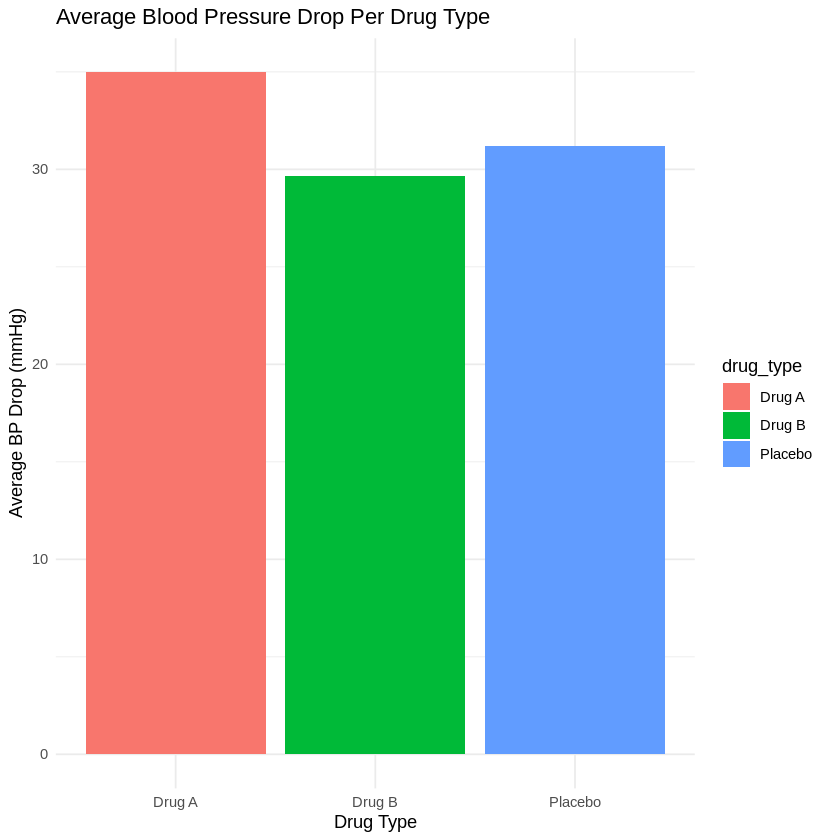

In [6]:
# Creating A Bar Plot To Compare Drug Efficacy
ggplot(data = drug_summary, aes(x = drug_type, y = average_BP_Drop, fill = drug_type)) + geom_col() + labs(
  title = "Average Blood Pressure Drop Per Drug Type" ,
  x = "Drug Type" ,
  y = "Average BP Drop (mmHg)"
) +
  theme_minimal() # Applies A Clean And Professional White Background